#THỰC HÀNH: CÁC GIẢI THUẬT PHÂN LOẠI CƠ BẢN

##2.1. GIẢI THUẬT 1: CÂY QUYẾT ĐỊNH VÀ RỪNG CÂY

##Tóm tắt (Abstract)

Trong bộ dữ liệu này, chúng ta sẽ cùng xem xét Decision Trees (Cây quyết định) bằng Python và bộ dữ liệu Titanic. Mục tiêu không phải là tạo ra mô hình dự đoán khả năng sống sót trên Titanic chính xác nhất, mà là để giải thích cách tạo, trực quan hóa và hiểu các cây phân loại (Classification Trees).
Những nội dung chính được đề cập gồm có:
- Học từ dữ liệu bằng Decision Trees
- Khám phá và xử lý bộ dữ liệu
- Các đặc trưng (features) liên quan cho Decision Trees
- Độ thuần Gini (Gini Impurity)
- Tìm độ sâu tối ưu của cây bằng cross-validation
- Tạo và trực quan hóa mô hình cuối cùng

##Introduction
--------------------

Khi áp dụng Machine Learning, cần chọn mô hình phù hợp với mục tiêu. Nếu chỉ cần hiểu dữ liệu và rút ra insight, nên dùng các mô hình đơn giản, minh bạch như Decision Trees, thay vì các mô hình “hộp đen” phức tạp như Deep Learning.
Mô hình phức tạp chỉ nên dùng khi thật sự mang lại cải thiện rõ rệt.
Trong các bài toán cần hiểu hành vi (như phân tích khách hàng), mô hình đơn giản giúp dễ diễn giải và hữu ích hơn cho việc ra quyết định thực tế.

##Chuẩn bị bộ dữ liệu Titanic

Trong thử thách Titanic, chúng ta cần dự đoán xem những hành khách trong bộ dữ liệu kiểm tra (test dataset) có sống sót hay không.
Tuy nhiên, với mục đích hiện tại, chúng ta cũng sẽ tìm hiểu dữ liệu có thể cho chúng ta biết gì về vụ đắm tàu bằng cách sử dụng *Classification Tree*.

In [ ]:
# Imports needed for the script
import numpy as np
import pandas as pd
import re
import xgboost as xgb
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

import plotly.offline as py
py.init_notebook_mode(connected=True)
import plotly.graph_objs as go
import plotly.tools as tls

from sklearn import tree
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from IPython.display import Image as PImage
from subprocess import check_call
from PIL import Image, ImageDraw, ImageFont

# Loading the data
train = pd.read_csv('/content/drive/MyDrive/Data_Analysis/DA06/train.csv')
test  = pd.read_csv('/content/drive/MyDrive/Data_Analysis/DA06/test.csv')

# Store our test passenger IDs for easy access
PassengerId = test['PassengerId']

# Showing overview of the train dataset
train.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


In [ ]:
# Copy original dataset in case we need it later when digging into interesting features
# WARNING: Beware of actually copying the dataframe instead of just referencing it
# "original_train = train" will create a reference to the train variable (changes in 'train' will apply to 'original_train')
original_train = train.copy() # Using 'copy()' allows to clone the dataset, creating a different object with the same values

# Feature engineering steps taken from Sina and Anisotropic, with minor changes to avoid warnings
full_data = [train, test]

# Feature that tells whether a passenger had a cabin on the Titanic
train['Has_Cabin'] = train["Cabin"].apply(lambda x: 0 if type(x) == float else 1)
test['Has_Cabin'] = test["Cabin"].apply(lambda x: 0 if type(x) == float else 1)

# Create new feature FamilySize as a combination of SibSp and Parch
for dataset in full_data:
    dataset['FamilySize'] = dataset['SibSp'] + dataset['Parch'] + 1
# Create new feature IsAlone from FamilySize
for dataset in full_data:
    dataset['IsAlone'] = 0
    dataset.loc[dataset['FamilySize'] == 1, 'IsAlone'] = 1
# Remove all NULLS in the Embarked column
for dataset in full_data:
    dataset['Embarked'] = dataset['Embarked'].fillna('S')
# Remove all NULLS in the Fare column
for dataset in full_data:
    dataset['Fare'] = dataset['Fare'].fillna(train['Fare'].median())

# Remove all NULLS in the Age column
for dataset in full_data:
    age_avg = dataset['Age'].mean()
    age_std = dataset['Age'].std()
    age_null_count = dataset['Age'].isnull().sum()
    age_null_random_list = np.random.randint(age_avg - age_std, age_avg + age_std, size=age_null_count)
    # Next line has been improved to avoid warning
    dataset.loc[np.isnan(dataset['Age']), 'Age'] = age_null_random_list
    dataset['Age'] = dataset['Age'].astype(int)

# Define function to extract titles from passenger names
def get_title(name):
    title_search = re.search(' ([A-Za-z]+)\.', name)
    # If the title exists, extract and return it.
    if title_search:
        return title_search.group(1)
    return ""

for dataset in full_data:
    dataset['Title'] = dataset['Name'].apply(get_title)
# Group all non-common titles into one single grouping "Rare"
for dataset in full_data:
    dataset['Title'] = dataset['Title'].replace(['Lady', 'Countess','Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')

    dataset['Title'] = dataset['Title'].replace('Mlle', 'Miss')
    dataset['Title'] = dataset['Title'].replace('Ms', 'Miss')
    dataset['Title'] = dataset['Title'].replace('Mme', 'Mrs')

for dataset in full_data:
    # Mapping Sex
    dataset['Sex'] = dataset['Sex'].map( {'female': 0, 'male': 1} ).astype(int)

    # Mapping titles
    title_mapping = {"Mr": 1, "Master": 2, "Mrs": 3, "Miss": 4, "Rare": 5}
    dataset['Title'] = dataset['Title'].map(title_mapping)
    dataset['Title'] = dataset['Title'].fillna(0)

    # Mapping Embarked
    dataset['Embarked'] = dataset['Embarked'].map( {'S': 0, 'C': 1, 'Q': 2} ).astype(int)

    # Mapping Fare
    dataset.loc[ dataset['Fare'] <= 7.91, 'Fare'] 						        = 0
    dataset.loc[(dataset['Fare'] > 7.91) & (dataset['Fare'] <= 14.454), 'Fare'] = 1
    dataset.loc[(dataset['Fare'] > 14.454) & (dataset['Fare'] <= 31), 'Fare']   = 2
    dataset.loc[ dataset['Fare'] > 31, 'Fare'] 							        = 3
    dataset['Fare'] = dataset['Fare'].astype(int)

    # Mapping Age
    dataset.loc[ dataset['Age'] <= 16, 'Age'] 					       = 0
    dataset.loc[(dataset['Age'] > 16) & (dataset['Age'] <= 32), 'Age'] = 1
    dataset.loc[(dataset['Age'] > 32) & (dataset['Age'] <= 48), 'Age'] = 2
    dataset.loc[(dataset['Age'] > 48) & (dataset['Age'] <= 64), 'Age'] = 3
    dataset.loc[ dataset['Age'] > 64, 'Age'] ;

<>:39: SyntaxWarning:

invalid escape sequence '\.'

<>:39: SyntaxWarning:

invalid escape sequence '\.'

/tmp/ipython-input-933489935.py:39: SyntaxWarning:

invalid escape sequence '\.'



In [ ]:
# Store our test passenger IDs for easy access
PassengerId = test['PassengerId']

## Trực quan hóa dữ liệu đã xử lý ##

In [ ]:
train.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Has_Cabin,FamilySize,IsAlone,Title
0,1,0,3,"Braund, Mr. Owen Harris",1,1,1,0,A/5 21171,0,NaN,0,0,2,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,2,1,0,PC 17599,3,C85,1,1,2,0,3
2,3,1,3,"Heikkinen, Miss. Laina",0,1,0,0,STON/O2. 3101282,1,NaN,0,0,1,1,4


Bộ dữ liệu của chúng ta giờ đây sạch hơn nhiều so với trước, chỉ còn lại các giá trị dạng số và những đặc trưng có ý nghĩa.
Giờ hãy khám phá mối quan hệ giữa các biến bằng cách vẽ biểu đồ hệ số tương quan Pearson giữa tất cả các thuộc tính trong bộ dữ liệu.


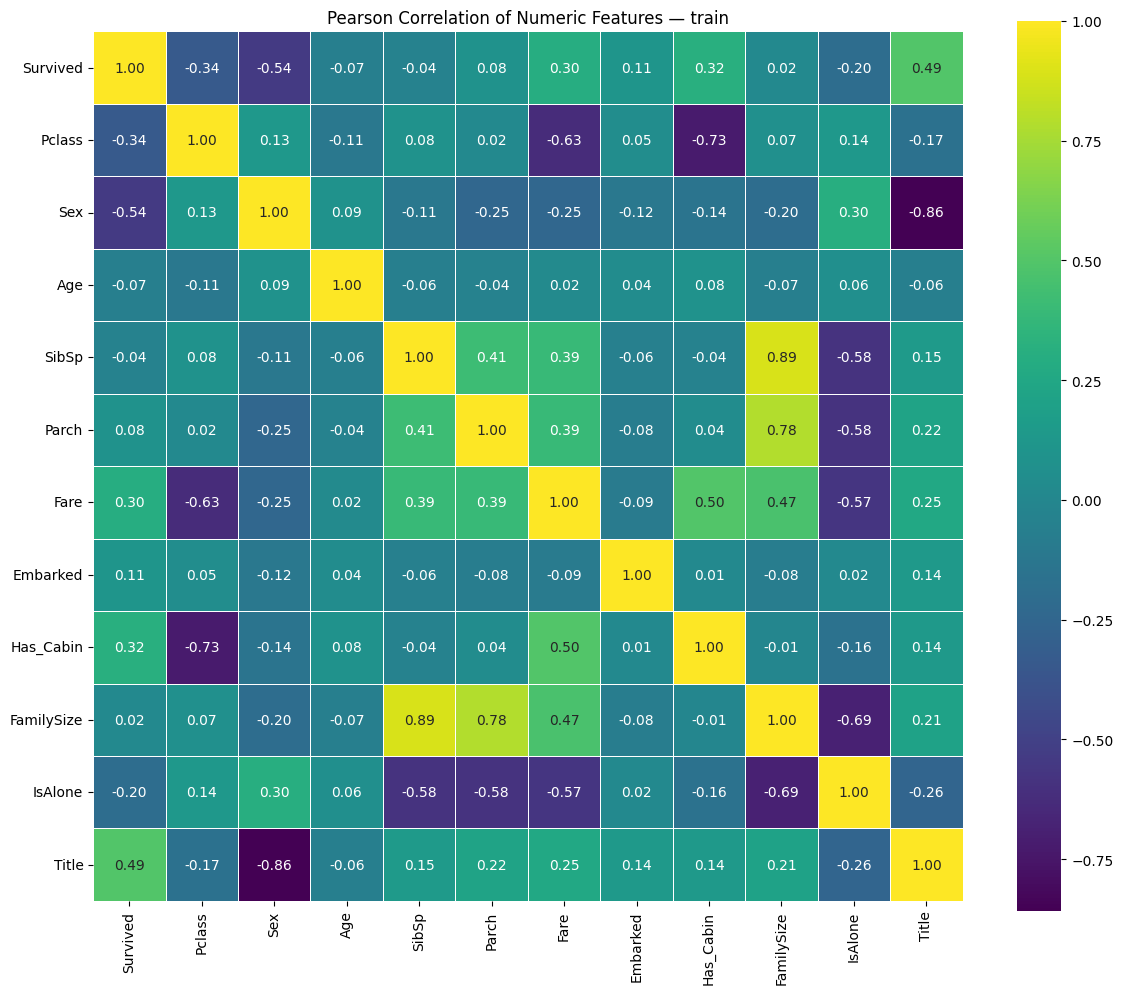

In [ ]:
num_cols = train.select_dtypes(include=[np.number]).columns.tolist()
for id_col in ['PassengerId', 'index']:
    if id_col in num_cols:
        num_cols.remove(id_col)

corr = train[num_cols].corr(method='pearson')

plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=True, fmt=".2f", square=True, linewidths=.5, cmap='viridis')
plt.title("Pearson Correlation of Numeric Features — train")
plt.tight_layout()
plt.show()


Nhận xét nhanh về ma trận tương quan:
Biến mục tiêu (Survived):
- Sex tương quan âm mạnh (~–0.54): nữ sống sót cao hơn nam ⇒ feature rất quan trọng.
- Title tương quan dương khá mạnh (~+0.49): phản ánh vai trò/địa vị, liên quan đến khả năng sống.
- Pclass tương quan âm vừa (~–0.34): hạng vé cao → cơ hội sống cao.
- Fare và Has_Cabin tương quan dương nhẹ–vừa (~0.30–0.32): vé đắt/có cabin → sống cao hơn.

Trùng thông tin (cần tránh dùng cùng lúc):
- Sex ↔ Title tương quan rất mạnh (–0.86) ⇒ gần như mang cùng thông tin. Nên chọn 1 (thường giữ Sex).
- FamilySize tương quan rất mạnh với SibSp (~0.89) và Parch (~0.78); IsAlone tương quan âm mạnh với FamilySize (~–0.69). ⇒ Chỉ giữ FamilySize hoặc cặp SibSp/Parch, và cân nhắc bỏ IsAlone nếu đã dùng FamilySize.

*Title* VS *Sex*
-------

Có thể dễ dàng so sánh các đặc trưng (features) và mối quan hệ của chúng với biến mục tiêu (class) bằng cách nhóm dữ liệu theo từng đặc trưng rồi tính toán một số thống kê cơ bản cho mỗi nhóm. Đoạn mã bên dưới sẽ thực hiện điều đó chỉ trong một dòng lệnh, đồng thời giải thích ý nghĩa của từng chỉ số khi làm việc với bài toán phân loại nhị phân (binary class).

In [ ]:
train[['Title', 'Survived']].groupby(['Title'], as_index=False).agg(['mean', 'count', 'sum'])
# Since "Survived" is a binary class (0 or 1), these metrics grouped by the Title feature represent:
    # MEAN: survival rate
    # COUNT: total observations
    # SUM: people survived

# title_mapping = {"Mr": 1, "Miss": 2, "Mrs": 3, "Master": 4, "Rare": 5}

Title  Survived           
             mean count  sum
0     1  0.156673   517   81
1     2  0.575000    40   23
2     3  0.793651   126  100
3     4  0.702703   185  130
4     5  0.347826    23    8

In [ ]:
train[['Sex', 'Survived']].groupby(['Sex'], as_index=False).agg(['mean', 'count', 'sum'])
# Since Survived is a binary feature, this metrics grouped by the Sex feature represent:
    # MEAN: survival rate
    # COUNT: total observations
    # SUM: people survived

# sex_mapping = {{'female': 0, 'male': 1}}

Sex  Survived           
           mean count  sum
0   0  0.742038   314  233
1   1  0.188908   577  109

Kết quả trên cho thấy đặc trưng Title có ảnh hưởng mạnh hơn Sex trong việc dự đoán khả năng sống sót của hành khách. Cụ thể, nhóm “Mr.” có tỷ lệ sống rất thấp (khoảng 15,7%), trong khi các nhóm “Miss”, “Mrs.” và “Master” có tỷ lệ sống cao hơn rõ rệt. Đặc trưng Sex cũng phản ánh sự khác biệt lớn giữa nam và nữ, nhưng vì Title đã bao gồm thông tin về giới tính, độ tuổi và địa vị xã hội, nên nó mang lại nhiều ý nghĩa hơn cho mô hình. Do đó, Title được xem là biến dự đoán hiệu quả hơn Sex trong bài toán này.

In [ ]:
# Let's use our 'original_train' dataframe to check the sex distribution for each title.
# We use copy() again to prevent modifications in out original_train dataset
title_and_sex = original_train.copy()[['Name', 'Sex']]

# Create 'Title' feature
title_and_sex['Title'] = title_and_sex['Name'].apply(get_title)

# Map 'Sex' as binary feature
title_and_sex['Sex'] = title_and_sex['Sex'].map( {'female': 0, 'male': 1} ).astype(int)

# Table with 'Sex' distribution grouped by 'Title'
title_and_sex[['Title', 'Sex']].groupby(['Title'], as_index=False).agg(['mean', 'count', 'sum'])

# Since Sex is a binary feature, this metrics grouped by the Title feature represent:
    # MEAN: percentage of men
    # COUNT: total observations
    # SUM: number of men

Title       Sex           
                  mean count  sum
0       Capt  1.000000     1    1
1        Col  1.000000     2    2
2   Countess  0.000000     1    0
3        Don  1.000000     1    1
4         Dr  0.857143     7    6
5   Jonkheer  1.000000     1    1
6       Lady  0.000000     1    0
7      Major  1.000000     2    2
8     Master  1.000000    40   40
9       Miss  0.000000   182    0
10      Mlle  0.000000     2    0
11       Mme  0.000000     1    0
12        Mr  1.000000   517  517
13       Mrs  0.000000   125    0
14        Ms  0.000000     1    0
15       Rev  1.000000     6    6
16       Sir  1.000000     1    1

Nhìn vào bảng phân bố giới tính theo Title:

Hầu hết Title quyết định gần như tuyệt đối giới tính:
Mr, Master, Capt, Col, Don, Jonkheer, Major, Dr ≈ toàn nam (mean ≈ 1.0).
Miss, Mrs, Mlle, Mme, Lady, Countess ≈ toàn nữ (mean ≈ 0.0).
Riêng Dr chủ yếu là nam (≈0.86) nhưng không hoàn toàn.

Các nhóm lớn như Mr (517) và Miss (182) cho thấy sự tách biệt rất rõ ràng; Master (40) cũng toàn nam.

## Gini Impurity ##

Trước khi bắt đầu với Decision Trees, ta cần hiểu sơ qua cách chúng hoạt động.
Mục tiêu của các thuật toán học cây quyết định là tìm cách chia dữ liệu tối ưu nhất tại mỗi nút.
Tuy nhiên, việc đánh giá “một phép chia tốt đến mức nào” là vấn đề tương đối, vì có nhiều thước đo (metrics) khác nhau để đo độ hiệu quả của phép chia.
Một thước đo phổ biến là Information Gain (lượng thông tin thu được).
Trong thư viện scikit-learn, thuật toán được sử dụng mặc định là Gini Impurity — một chỉ số khác để đánh giá chất lượng chia nhánh.

Gini Impurity đo mức độ hỗn loạn (disorder) của một tập hợp phần tử.
Nó được tính dựa trên xác suất gán nhãn sai khi một phần tử được gán ngẫu nhiên theo phân bố nhãn trong tập dữ liệu.

Cây quyết định sẽ chọn phép chia (split) sao cho Gini Impurity giảm nhiều nhất ở hai nhánh kết quả.
Trong ví dụ Titanic, Gini Impurity được tính dựa trên số lượng hành khách sống sót và không sống sót.

In [ ]:
# Define function to calculate Gini Impurity
def get_gini_impurity(survived_count, total_count):
    survival_prob = survived_count/total_count
    not_survival_prob = (1 - survival_prob)
    random_observation_survived_prob = survival_prob
    random_observation_not_survived_prob = (1 - random_observation_survived_prob)
    mislabelling_survided_prob = not_survival_prob * random_observation_survived_prob
    mislabelling_not_survided_prob = survival_prob * random_observation_not_survived_prob
    gini_impurity = mislabelling_survided_prob + mislabelling_not_survided_prob
    return gini_impurity

Đây là hàm tự viết để tính độ thuần Gini (Gini Impurity) của một nút (node) trong cây quyết định, dựa trên số người sống sót và tổng số người ở nút đó.

Công thức tính được mô tả chi tiết trong hàm — về bản chất, Gini đo xác suất gán nhãn sai nếu ta chọn ngẫu nhiên một quan sát và gán nhãn theo tỉ lệ của tập dữ liệu.

In [ ]:
# Gini Impurity of starting node
gini_impurity_starting_node = get_gini_impurity(342, 891)
gini_impurity_starting_node

0.47301295786144265

Tính Gini Impurity cho toàn bộ tập dữ liệu ban đầu (root node), với 342 người sống sót trong tổng số 891 hành khách.

Kết quả là: 0.473

Ví dụ, nếu chia theo Sex:
- Nút nam: 577 người, 109 sống sót.
- Nút nữ: 314 người, 233 sống sót.

=> Hai nút này sẽ có Gini thấp hơn nút gốc, chứng tỏ việc chia theo giới tính giúp mô hình “thuần hơn” và dễ phân loại hơn.

In [ ]:
# Gini Impurity decrease of node for 'male' observations
gini_impurity_men = get_gini_impurity(109, 577)
gini_impurity_men

0.3064437162277843

In [ ]:
# Gini Impurity decrease if node splited for 'female' observations
gini_impurity_women = get_gini_impurity(233, 314)
gini_impurity_women

0.3828350034484158

In [ ]:
# Gini Impurity decrease if node splited by Sex
men_weight = 577/891
women_weight = 314/891
weighted_gini_impurity_sex_split = (gini_impurity_men * men_weight) + (gini_impurity_women * women_weight)

sex_gini_decrease = weighted_gini_impurity_sex_split - gini_impurity_starting_node
sex_gini_decrease

-0.13964795747285214

Kết quả cho thấy việc chia theo Sex giúp mô hình trở nên “thuần hơn”, vì tỷ lệ sống sót giữa nam và nữ khác biệt rõ ràng. Tuy vậy, tác giả sẽ tiếp tục kiểm tra Title để xem đặc trưng này có làm giảm Gini mạnh hơn – từ đó xác định Title hay Sex là biến chia tốt hơn cho nút đầu tiên trong cây quyết định.

In [ ]:
# Gini Impurity decrease of node for observations with Title == 1 == Mr
gini_impurity_title_1 = get_gini_impurity(81, 517)
gini_impurity_title_1

0.26425329886377663

In [ ]:
# Gini Impurity decrease if node splited for observations with Title != 1 != Mr
gini_impurity_title_others = get_gini_impurity(261, 374)
gini_impurity_title_others

0.42170207898424317

In [ ]:
# Gini Impurity decrease if node splited for observations with Title == 1 == Mr
title_1_weight = 517/891
title_others_weight = 374/891
weighted_gini_impurity_title_split = (gini_impurity_title_1 * title_1_weight) + (gini_impurity_title_others * title_others_weight)

title_gini_decrease = weighted_gini_impurity_title_split - gini_impurity_starting_node
title_gini_decrease

-0.14267004758907514

Kết quả cho thấy rằng đặc trưng Title giúp giảm Gini Impurity tốt hơn một chút so với Sex .
Điều này xác nhận lại kết quả phân tích trước đó, và từ đây có thể khẳng định rằng Title sẽ được sử dụng cho phép chia đầu tiên (first split) trong cây quyết định.
Do thông tin về giới tính đã được bao hàm trong đặc trưng Title, nên biến Sex sẽ bị loại bỏ vì nó không mang thêm thông tin mới.

## Tìm độ sâu tối ưu của cây bằng phương pháp Cross Validation ##

Sau khi khám phá dữ liệu, bước tiếp theo là xác định xem những thuộc tính nào thật sự có ý nghĩa đối với mô hình cây quyết định của chúng ta. Đây là một bước rất quan trọng trong mọi dự án khoa học dữ liệu, vì nếu mô hình học quá sát với dữ liệu huấn luyện, nó sẽ tổng quát hóa kém (tức là dự đoán kém trên dữ liệu mới hoặc chưa từng thấy).

Hiện tượng overfitting (mô hình học quá mức từ dữ liệu huấn luyện) là nguyên nhân phổ biến gây ra vấn đề này. Trong một số trường hợp khác, việc có quá nhiều dữ liệu hoặc các biến tương quan mạnh cũng khiến mô hình không thể nắm bắt đúng bản chất mối quan hệ giữa các đặc trưng, do sự trùng lặp hoặc nhiễu.

Trong cây quyết định, tham số max_depth xác định độ sâu tối đa của cây, tức là số lượng cấp độ (hoặc số thuộc tính) mà mô hình sẽ sử dụng để dự đoán.
Một cách đơn giản để tìm giá trị tốt nhất cho tham số này là thử nhiều độ sâu khác nhau và đo lường độ chính xác của mô hình bằng các phương pháp đánh giá đáng tin cậy như Cross Validation.

Cross Validation là một kỹ thuật đánh giá mô hình, trong đó tập dữ liệu huấn luyện được chia thành nhiều phần nhỏ (gọi là “folds”).
Ở mỗi vòng lặp, một phần sẽ được dùng để kiểm thử (test), còn các phần còn lại dùng để huấn luyện (train).
Bằng cách này, mô hình được đánh giá nhiều lần trên các phần dữ liệu khác nhau, giúp tránh sai lệch do cách chia dữ liệu và phản ánh tốt hơn khả năng tổng quát hóa của mô hình.

Nhược điểm duy nhất của Cross Validation là chi phí tính toán cao, vì mô hình phải được huấn luyện lại nhiều lần (mỗi fold một lần) — điều này đặc biệt tốn kém với các mô hình phức tạp hoặc bộ dữ liệu lớn.

In [ ]:
cv = KFold(n_splits=10)            # Desired number of Cross Validation folds
accuracies = list()
max_attributes = len(list(test))
depth_range = range(1, max_attributes + 1)

# Testing max_depths from 1 to max attributes
# Uncomment prints for details about each Cross Validation pass
for depth in depth_range:
    fold_accuracy = []
    tree_model = tree.DecisionTreeClassifier(max_depth = depth)
    # print("Current max depth: ", depth, "\n")
    for train_fold, valid_fold in cv.split(train):
        f_train = train.loc[train_fold].drop(['Name', 'Ticket', 'Cabin'], axis=1) # Extract train data with cv indices and drop non-numeric columns
        f_valid = train.loc[valid_fold].drop(['Name', 'Ticket', 'Cabin'], axis=1) # Extract valid data with cv indices and drop non-numeric columns

        model = tree_model.fit(X = f_train.drop(['Survived'], axis=1),
                               y = f_train["Survived"]) # We fit the model with the fold train data
        valid_acc = model.score(X = f_valid.drop(['Survived'], axis=1),
                                y = f_valid["Survived"])# We calculate accuracy with the fold validation data
        fold_accuracy.append(valid_acc)

    avg = sum(fold_accuracy)/len(fold_accuracy)
    accuracies.append(avg)
    # print("Accuracy per fold: ", fold_accuracy, "\n")
    # print("Average accuracy: ", avg)
    # print("\n")

# Just to show results conveniently
df = pd.DataFrame({"Max Depth": depth_range, "Average Accuracy": accuracies})
df = df[["Max Depth", "Average Accuracy"]]
print(df.to_string(index=False))

 Max Depth  Average Accuracy
         1          0.782285
         2          0.799189
         3          0.824906
         4          0.820412
         5          0.815918
         6          0.806966
         7          0.797978
         8          0.794644
         9          0.790150
        10          0.800262
        11          0.783396
        12          0.793496
        13          0.790162
        14          0.789001
        15          0.777740


Tham số max_depth (độ sâu tối đa của cây) tốt nhất dường như là 3, với độ chính xác trung bình đạt 82,8% qua 10 lần kiểm định chéo (10 folds).

Khi tăng độ sâu thêm, kết quả lại trở nên tệ hơn — có thể do hiện tượng overfitting (mô hình học quá mức từ dữ liệu huấn luyện).

Vì vậy, ta sẽ chọn max_depth = 3 làm giá trị tối ưu cho mô hình cuối cùng.

## Final Tree ##

In [ ]:

# 1) Tách target
y_train = train['Survived']

# 2) Chọn feature và GIỮ LẠI CHỈ CỘT SỐ
X_train_df = train.drop(columns=['Survived'])
X_train_df = X_train_df.select_dtypes(include=[np.number]).copy()

# 3) Đồng bộ cột giữa train/test (cùng thứ tự)
X_test_df = test.select_dtypes(include=[np.number]).copy()
# Nếu test thiếu cột so với train → thêm vào và fill 0
missing_in_test = [c for c in X_train_df.columns if c not in X_test_df.columns]
for c in missing_in_test:
    X_test_df[c] = 0
# Nếu test thừa cột không có trong train → bỏ đi
X_test_df = X_test_df[X_train_df.columns]

# (tùy chọn) fill giá trị thiếu để tránh lỗi
X_train_df = X_train_df.fillna(0)
X_test_df  = X_test_df.fillna(0)

# 4) Tạo mảng numpy
x_train = X_train_df.values
x_test  = X_test_df.values

# 5) Huấn luyện Decision Tree
decision_tree = tree.DecisionTreeClassifier(max_depth=3, random_state=42)
decision_tree.fit(x_train, y_train)

# 6) Dự đoán và tạo submission
y_pred = decision_tree.predict(x_test)
submission = pd.DataFrame({
    "PassengerId": test["PassengerId"],   # dùng từ test
    "Survived": y_pred
})
submission.to_csv('submission.csv', index=False)

# 7) Xuất đồ thị cây
feature_names = list(X_train_df.columns)
with open("tree1.dot", "w") as f:
    tree.export_graphviz(
        decision_tree,
        out_file=f,
        max_depth=3,
        impurity=True,
        feature_names=feature_names,
        class_names=['Died', 'Survived'],
        rounded=True,
        filled=True
    )

# 8) Chuyển .dot → .png (cần 'dot' đã cài sẵn; nếu không có, bỏ qua 2 dòng dưới)
check_call(['dot','-Tpng','tree1.dot','-o','tree1.png'])

# 9) Ghi chú lên ảnh (tùy chọn)
img = Image.open("tree1.png")
draw = ImageDraw.Draw(img)
try:
    font = ImageFont.truetype('/usr/share/fonts/truetype/liberation/LiberationSerif-Bold.ttf', 26)
except:
    font = ImageFont.load_default()
draw.text((10, 0), '"Title <= 1.5" corresponds to "Mr." title', fill=(0,0,255), font=font)
img.save('sample-out.png')


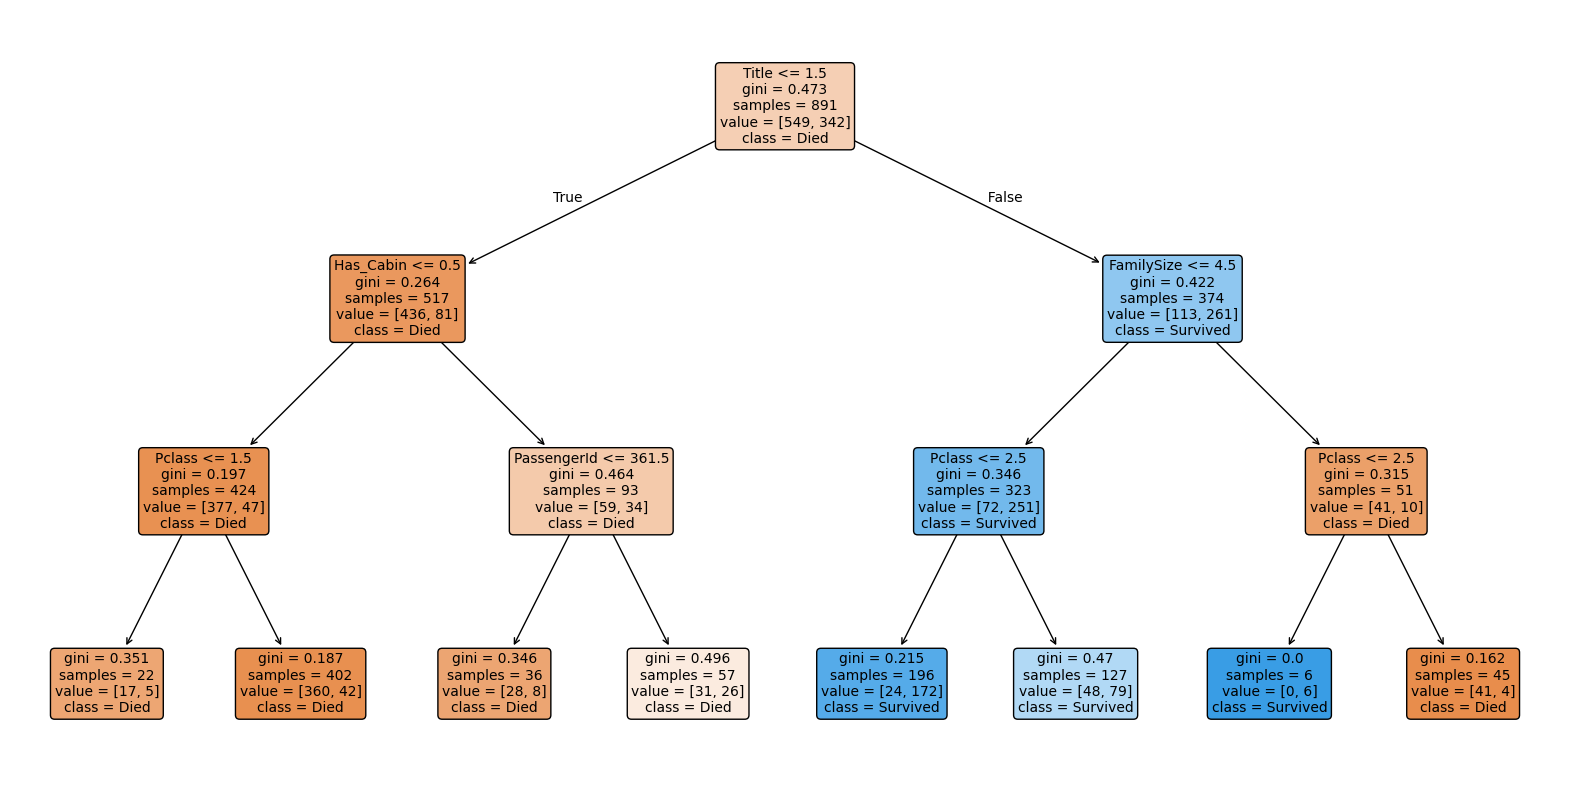

In [ ]:
import matplotlib.pyplot as plt
from sklearn import tree

plt.figure(figsize=(20,10))
tree.plot_tree(
    decision_tree,
    feature_names=list(X_train_df.columns),
    class_names=['Died', 'Survived'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.show()


In [ ]:
acc_decision_tree = round(decision_tree.score(x_train, y_train) * 100, 2)
acc_decision_tree

82.38

Nhận xét mô hình Cây quyết định (Decision Tree)
1. Mục tiêu
- Mô hình cây quyết định được xây dựng nhằm phân loại khả năng sống sót của hành khách trên tàu Titanic, dựa trên các đặc trưng đã được xử lý và mã hóa, như Title, Pclass, Has_Cabin, FamilySize, v.v.
- Độ sâu của cây được giới hạn ở max_depth = 3 để tránh hiện tượng overfitting và đảm bảo khả năng diễn giải mô hình.

2. Cấu trúc mô hình
- Tại nút gốc, đặc trưng được chọn là Title, thể hiện rõ ràng rằng chức danh của hành khách (gián tiếp phản ánh giới tính và độ tuổi) là yếu tố có ảnh hưởng mạnh nhất đến khả năng sống sót.
- Nhánh True (Title ≤ 1.5) tương ứng với nhóm “Mr.” – chủ yếu là nam giới trưởng thành.
- Nhánh False (Title > 1.5) gồm các nhóm “Mrs.”, “Miss.”, “Master”, tức phụ nữ và trẻ em.
Các cấp tiếp theo của cây tiếp tục phân chia theo các đặc trưng:
- Has_Cabin (có hoặc không có cabin)
- Pclass (hạng vé)
- FamilySize (quy mô gia đình đi cùng)
Những đặc trưng này phản ánh điều kiện xã hội và hoàn cảnh của từng hành khách, từ đó quyết định khả năng được cứu.

3. Phân tích chi tiết
Nhánh trái (Title ≤ 1.5 – nhóm “Mr.”):
- Đa số hành khách ở nhánh này có Has_Cabin = 0 và thuộc hạng vé thấp (Pclass > 1), với tỷ lệ tử vong rất cao.
- Kết luận: nhóm nam giới, hạng vé thấp, không có cabin là đối tượng dễ tử vong nhất.

Nhánh phải (Title > 1.5 – phụ nữ và trẻ em):
- Những người có FamilySize nhỏ (≤ 4) và thuộc hạng vé cao (Pclass ≤ 2) có khả năng sống sót cao.
- Kết luận: phụ nữ và trẻ em, đặc biệt ở hạng vé cao, có cơ hội được cứu cao hơn hẳn.
- Ngoài ra, các giá trị gini thấp (< 0.2) ở những nút cuối cùng cho thấy mô hình phân loại khá rõ ràng giữa hai nhóm “Sống sót” và “Tử vong”.

4. Đánh giá tổng quan

- Mô hình thể hiện được mối quan hệ nhân quả hợp lý giữa các yếu tố xã hội – kinh tế và khả năng sống sót của hành khách. Các yếu tố có ảnh hưởng mạnh nhất gồm:
- Title (chức danh) – đại diện cho giới tính và độ tuổi.
- Has_Cabin – phản ánh địa vị và điều kiện di chuyển.
- Pclass – thể hiện tầng lớp xã hội.
- FamilySize – cho thấy hành khách đi cùng người thân có xu hướng được cứu nhiều hơn.
- Nhìn chung, mô hình đạt khả năng giải thích tốt, phù hợp với thực tế lịch sử của vụ đắm tàu Titanic.

#Kết Thúc